In [2]:
# ============================================
# MuseMirror AI — V2 Setup Cell
# ============================================

%pip install -q \
    librosa \
    soundfile \
    numpy \
    pandas \
    matplotlib \
    gdown \
    google-genai \
    python-dotenv

print("🔥 MuseMirror V2 setup complete")
print("🎧 Audio intelligence + Gemini layer ready")

Note: you may need to restart the kernel to use updated packages.
🔥 MuseMirror V2 setup complete
🎧 Audio intelligence + Gemini layer ready


In [3]:
# ============================================
# MuseMirror AI — V2 Imports & Configuration
# ============================================

import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import gdown

from dotenv import load_dotenv
from google import genai

# ----------------------------
# Locate project root
# ----------------------------

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# ----------------------------
# Load Gemini API key
# ----------------------------

load_dotenv(PROJECT_ROOT / ".env")

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError("❌ GEMINI_API_KEY not found in .env")

gemini_client = genai.Client(api_key=GEMINI_API_KEY)

GEMINI_MODEL = "gemini-3.6-flash"

# ----------------------------
# Demo audio configuration
# ----------------------------

FILE_ID = "18ZKdVrRHYmjbU6uzAQ88ul3PY7DUTVZN"
FILE_NAME = "Is this what i owe.mp3"

print("🔥 MuseMirror V2 imports loaded")
print("🔑 Gemini API key detected")
print(f"🧠 Gemini model: {GEMINI_MODEL}")
print(f"🎧 Demo track: {FILE_NAME}")

🔥 MuseMirror V2 imports loaded
🔑 Gemini API key detected
🧠 Gemini model: gemini-3.6-flash
🎧 Demo track: Is this what i owe.mp3


In [4]:
# ============================================
# MuseMirror AI — V2 Download Audio
# ============================================

import os
import gdown

# ----------------------------
# Download from Google Drive
# ----------------------------
if not os.path.exists(FILE_NAME):
    print("⬇️ Downloading audio file...")
    url = f"https://drive.google.com/uc?id={FILE_ID}"
    gdown.download(url, FILE_NAME, quiet=False)
else:
    print("⚡ File already exists, skipping download")

# ----------------------------
# Validate file
# ----------------------------
if os.path.exists(FILE_NAME):
    file_size_mb = os.path.getsize(FILE_NAME) / (1024 * 1024)
    print(f"✅ File ready: {FILE_NAME}")
    print(f"📦 Size: {file_size_mb:.2f} MB")
else:
    raise FileNotFoundError("❌ Download failed. File not found.")

# Set path for downstream cells
file_path = FILE_NAME

⬇️ Downloading audio file...


Downloading...
From: https://drive.google.com/uc?id=18ZKdVrRHYmjbU6uzAQ88ul3PY7DUTVZN
To: c:\Users\User\Desktop\projects\musemirror-ai\notebooks\Is this what i owe.mp3
100%|██████████| 10.9M/10.9M [00:02<00:00, 4.32MB/s]

✅ File ready: Is this what i owe.mp3
📦 Size: 10.35 MB


In [5]:
# ============================================
# MuseMirror AI — V2 Load Audio
# ============================================

# ----------------------------
# Load audio
# ----------------------------
y, sr = librosa.load(file_path, sr=None, mono=True)

# ----------------------------
# Basic metadata
# ----------------------------
duration_sec = librosa.get_duration(y=y, sr=sr)
total_samples = len(y)
time_axis = np.linspace(0, duration_sec, total_samples)

audio_info = {
    "file_name": file_path,
    "sample_rate": int(sr),
    "duration_sec": float(duration_sec),
    "total_samples": int(total_samples),
    "waveform_shape": tuple(y.shape),
    "peak_amplitude": float(np.max(np.abs(y))),
    "mean_amplitude": float(np.mean(np.abs(y)))
}

print("✅ Audio loaded successfully\n")
print(f"📁 File Name      : {audio_info['file_name']}")
print(f"🎧 Sample Rate    : {audio_info['sample_rate']} Hz")
print(f"⏱️ Duration       : {audio_info['duration_sec']:.2f} sec")
print(f"🔢 Total Samples  : {audio_info['total_samples']}")
print(f"📐 Waveform Shape : {audio_info['waveform_shape']}")
print(f"📈 Peak Amplitude : {audio_info['peak_amplitude']:.6f}")
print(f"📊 Mean Amplitude : {audio_info['mean_amplitude']:.6f}")

c:\Users\User\Desktop\projects\musemirror-ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Audio loaded successfully

📁 File Name      : Is this what i owe.mp3
🎧 Sample Rate    : 44100 Hz
⏱️ Duration       : 271.18 sec
🔢 Total Samples  : 11958976
📐 Waveform Shape : (11958976,)
📈 Peak Amplitude : 1.330485
📊 Mean Amplitude : 0.122692


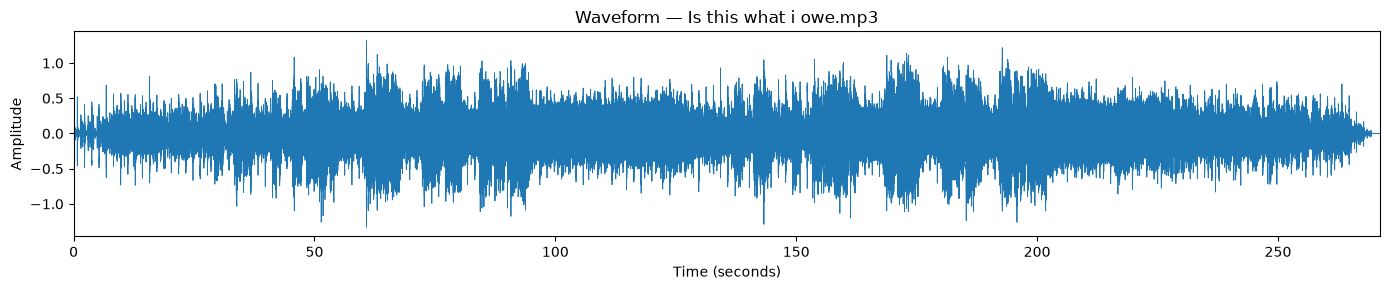

In [6]:
# ============================================
# MuseMirror AI — V2 Waveform Visualization
# ============================================

plt.figure(figsize=(14, 3))
plt.plot(time_axis, y, linewidth=0.6)
plt.axhline(0, linewidth=0.8)

plt.title(f"Waveform — {audio_info['file_name']}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.xlim(0, duration_sec)
plt.tight_layout()
plt.show()

In [7]:
# ============================================
# MuseMirror AI — V2 Cell 6.1
# Beat Tracking + Tempo Interpretation
# ============================================

# ----------------------------
# Detect raw tempo and beat frames
# ----------------------------
tempo_raw, beat_frames = librosa.beat.beat_track(y=y, sr=sr)
tempo_raw_bpm = float(np.asarray(tempo_raw).item())
beat_times_sec = librosa.frames_to_time(beat_frames, sr=sr)

# ----------------------------
# Generate tempo candidates
# ----------------------------
tempo_candidates = {
    "half_time": tempo_raw_bpm / 2,
    "normal": tempo_raw_bpm,
    "double_time": tempo_raw_bpm * 2
}

# Keep only musically reasonable values
valid_tempo_candidates = {
    mode: float(bpm)
    for mode, bpm in tempo_candidates.items()
    if 40 <= bpm <= 220
}

# ----------------------------
# Choose perceived tempo
# Prefer main pulse range: 60–125 BPM
# ----------------------------
preferred_candidates = {
    mode: bpm
    for mode, bpm in valid_tempo_candidates.items()
    if 60 <= bpm <= 125
}

if preferred_candidates:
    # Pick candidate closest to a practical pulse center
    selected_mode, tempo_adjusted_bpm = min(
        preferred_candidates.items(),
        key=lambda item: abs(item[1] - 85)
    )
else:
    selected_mode = "normal"
    tempo_adjusted_bpm = tempo_raw_bpm

# ----------------------------
# Interpret tempo mode
# ----------------------------
tempo_ratio = tempo_raw_bpm / (tempo_adjusted_bpm + 1e-10)

if abs(tempo_ratio - 1.0) < 0.15:
    tempo_mode = "normal"
    tempo_mode_note = "Raw tempo already matches the perceived pulse"
elif abs(tempo_ratio - 2.0) < 0.25:
    tempo_mode = "double_time"
    tempo_mode_note = "Double-time detection corrected"
elif abs(tempo_ratio - 0.5) < 0.15:
    tempo_mode = "half_time"
    tempo_mode_note = "Half-time detection corrected"
else:
    tempo_mode = selected_mode
    tempo_mode_note = "Closest musically reasonable pulse selected"

# ----------------------------
# Structured tempo summary
# ----------------------------
tempo_summary = {
    "tempo_raw_bpm": float(tempo_raw_bpm),
    "tempo_adjusted_bpm": float(tempo_adjusted_bpm),
    "tempo_ratio": float(tempo_ratio),
    "tempo_mode": tempo_mode,
    "tempo_mode_note": tempo_mode_note,
    "tempo_candidates_bpm": {
        k: round(v, 2) for k, v in valid_tempo_candidates.items()
    },
    "num_detected_beats": int(len(beat_frames)),
    "beat_times_sec": beat_times_sec.tolist()
}

# ----------------------------
# Display
# ----------------------------
print("✅ Tempo system refined successfully\n")

print("🎵 Tempo Analysis")
print(f"Perceived Tempo           : {tempo_summary['tempo_adjusted_bpm']:.2f} BPM")
print(f"Detected Raw Tempo        : {tempo_summary['tempo_raw_bpm']:.2f} BPM")
print(f"Tempo Ratio (raw/adjusted): {tempo_summary['tempo_ratio']:.2f}")
print(f"Tempo Mode                : {tempo_summary['tempo_mode']}")
print(f"Interpretation            : {tempo_summary['tempo_mode_note']}")
print(f"Tempo Candidates          : {tempo_summary['tempo_candidates_bpm']}")
print(f"Detected Beats            : {tempo_summary['num_detected_beats']}")

✅ Tempo system refined successfully

🎵 Tempo Analysis
Perceived Tempo           : 80.75 BPM
Detected Raw Tempo        : 161.50 BPM
Tempo Ratio (raw/adjusted): 2.00
Tempo Mode                : double_time
Interpretation            : Double-time detection corrected
Tempo Candidates          : {'half_time': 80.75, 'normal': 161.5}
Detected Beats            : 719


In [8]:
# ============================================
# MuseMirror AI — V2 Cell 6.2
# Core Audio Feature Extraction
# ============================================

# ----------------------------
# Frame-level features
# ----------------------------
rms_frames = librosa.feature.rms(y=y)[0]
spectral_centroid_frames = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
zcr_frames = librosa.feature.zero_crossing_rate(y)[0]

# ----------------------------
# Summary statistics
# ----------------------------
core_features = {
    "rms_energy_mean": float(np.mean(rms_frames)),
    "rms_energy_std": float(np.std(rms_frames)),
    "spectral_centroid_mean": float(np.mean(spectral_centroid_frames)),
    "spectral_centroid_std": float(np.std(spectral_centroid_frames)),
    "zero_crossing_rate_mean": float(np.mean(zcr_frames)),
    "zero_crossing_rate_std": float(np.std(zcr_frames))
}

# ----------------------------
# Keep reusable raw arrays too
# ----------------------------
frame_features = {
    "rms_frames": rms_frames,
    "spectral_centroid_frames": spectral_centroid_frames,
    "zcr_frames": zcr_frames
}

# ----------------------------
# Display
# ----------------------------
print("✅ Core audio features extracted\n")

print("📈 Core Feature Summary")
print(f"Mean RMS Energy             : {core_features['rms_energy_mean']:.6f}")
print(f"RMS Energy Std              : {core_features['rms_energy_std']:.6f}")
print(f"Mean Spectral Centroid      : {core_features['spectral_centroid_mean']:.2f}")
print(f"Spectral Centroid Std       : {core_features['spectral_centroid_std']:.2f}")
print(f"Mean Zero Crossing Rate     : {core_features['zero_crossing_rate_mean']:.6f}")
print(f"Zero Crossing Rate Std      : {core_features['zero_crossing_rate_std']:.6f}")

✅ Core audio features extracted

📈 Core Feature Summary
Mean RMS Energy             : 0.151510
RMS Energy Std              : 0.072423
Mean Spectral Centroid      : 2265.72
Spectral Centroid Std       : 1205.79
Mean Zero Crossing Rate     : 0.046465
Zero Crossing Rate Std      : 0.037299


In [9]:
# ============================================
# MuseMirror AI — V2 Cell 6.3
# Build Rhythm + Core Analysis Object
# ============================================

# ----------------------------
# Combine rhythm + core features
# ----------------------------
rhythm_core_analysis = {
    "rhythm": tempo_summary,
    "core_features": core_features
}

# ----------------------------
# Compact preview for debugging
# ----------------------------
print("✅ rhythm_core_analysis created successfully\n")

print("Top-level keys:")
for key in rhythm_core_analysis.keys():
    print(f"- {key}")

print("\n🎵 Rhythm Snapshot")
print(f"Perceived Tempo : {rhythm_core_analysis['rhythm']['tempo_adjusted_bpm']:.2f} BPM")
print(f"Detected Tempo  : {rhythm_core_analysis['rhythm']['tempo_raw_bpm']:.2f} BPM")
print(f"Tempo Mode      : {rhythm_core_analysis['rhythm']['tempo_mode']}")

print("\n📈 Core Snapshot")
print(f"Mean RMS        : {rhythm_core_analysis['core_features']['rms_energy_mean']:.6f}")
print(f"Mean Centroid   : {rhythm_core_analysis['core_features']['spectral_centroid_mean']:.2f}")
print(f"Mean ZCR        : {rhythm_core_analysis['core_features']['zero_crossing_rate_mean']:.6f}")

✅ rhythm_core_analysis created successfully

Top-level keys:
- rhythm
- core_features

🎵 Rhythm Snapshot
Perceived Tempo : 80.75 BPM
Detected Tempo  : 161.50 BPM
Tempo Mode      : double_time

📈 Core Snapshot
Mean RMS        : 0.151510
Mean Centroid   : 2265.72
Mean ZCR        : 0.046465


In [10]:
# ============================================
# MuseMirror AI — V2 Cell 7.1
# Timbre + Harmonic Feature Extraction
# ============================================

# ----------------------------
# MFCCs
# ----------------------------
N_MFCC = 13
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
mfcc_mean = np.mean(mfcc, axis=1)
mfcc_std = np.std(mfcc, axis=1)

# ----------------------------
# Chroma
# ----------------------------
chroma = librosa.feature.chroma_stft(y=y, sr=sr)
chroma_mean = np.mean(chroma, axis=1)
chroma_std = np.std(chroma, axis=1)

chroma_labels = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

# ----------------------------
# Structured summaries
# ----------------------------
mfcc_summary = {
    f"mfcc_{i+1}": {
        "mean": float(mfcc_mean[i]),
        "std": float(mfcc_std[i])
    }
    for i in range(N_MFCC)
}

chroma_summary = {
    chroma_labels[i]: {
        "mean": float(chroma_mean[i]),
        "std": float(chroma_std[i])
    }
    for i in range(len(chroma_labels))
}

timbre_harmonic_analysis = {
    "mfcc_summary": mfcc_summary,
    "chroma_summary": chroma_summary
}

# ----------------------------
# Display
# ----------------------------
print("✅ Timbre and harmonic features extracted\n")

print("🎚️ MFCC Summary")
for key, stats in mfcc_summary.items():
    print(f"{key.upper():<8} | mean: {stats['mean']:.4f} | std: {stats['std']:.4f}")

print("\n🎼 Chroma Summary")
for key, stats in chroma_summary.items():
    print(f"{key:<3} | mean: {stats['mean']:.4f} | std: {stats['std']:.4f}")

✅ Timbre and harmonic features extracted

🎚️ MFCC Summary
MFCC_1   | mean: -158.6728 | std: 84.4816
MFCC_2   | mean: 158.5991 | std: 43.9043
MFCC_3   | mean: -14.0623 | std: 26.3866
MFCC_4   | mean: 26.0034 | std: 18.0223
MFCC_5   | mean: 12.3301 | std: 20.7658
MFCC_6   | mean: 11.0378 | std: 13.3036
MFCC_7   | mean: 1.5473 | std: 10.3193
MFCC_8   | mean: 9.2982 | std: 9.3852
MFCC_9   | mean: -3.5738 | std: 7.7076
MFCC_10  | mean: -3.0735 | std: 8.0134
MFCC_11  | mean: -0.6066 | std: 8.2633
MFCC_12  | mean: 3.0489 | std: 7.6081
MFCC_13  | mean: -2.9835 | std: 7.0450

🎼 Chroma Summary
C   | mean: 0.3621 | std: 0.2711
C#  | mean: 0.3459 | std: 0.2615
D   | mean: 0.4142 | std: 0.3088
D#  | mean: 0.4647 | std: 0.2972
E   | mean: 0.5301 | std: 0.3353
F   | mean: 0.4212 | std: 0.2791
F#  | mean: 0.3833 | std: 0.2681
G   | mean: 0.4313 | std: 0.3235
G#  | mean: 0.4282 | std: 0.2793
A   | mean: 0.4952 | std: 0.3327
A#  | mean: 0.4595 | std: 0.2903
B   | mean: 0.4537 | std: 0.3248


In [11]:
# ============================================
# MuseMirror AI — V2 Cell 7.2
# Timbre + Harmonic Analysis Object Preview
# ============================================

print("✅ timbre_harmonic_analysis created successfully\n")

print("Top-level keys:")
for key in timbre_harmonic_analysis.keys():
    print(f"- {key}")

print("\n🎚️ MFCC Snapshot")
for key in list(timbre_harmonic_analysis["mfcc_summary"].keys())[:3]:
    stats = timbre_harmonic_analysis["mfcc_summary"][key]
    print(f"{key.upper():<8} | mean: {stats['mean']:.4f} | std: {stats['std']:.4f}")

print("\n🎼 Chroma Snapshot")
for key in ["C", "E", "G", "A"]:
    stats = timbre_harmonic_analysis["chroma_summary"][key]
    print(f"{key:<3} | mean: {stats['mean']:.4f} | std: {stats['std']:.4f}")

✅ timbre_harmonic_analysis created successfully

Top-level keys:
- mfcc_summary
- chroma_summary

🎚️ MFCC Snapshot
MFCC_1   | mean: -158.6728 | std: 84.4816
MFCC_2   | mean: 158.5991 | std: 43.9043
MFCC_3   | mean: -14.0623 | std: 26.3866

🎼 Chroma Snapshot
C   | mean: 0.3621 | std: 0.2711
E   | mean: 0.5301 | std: 0.3353
G   | mean: 0.4313 | std: 0.3235
A   | mean: 0.4952 | std: 0.3327


In [12]:
# ============================================
# MuseMirror AI — V2 Cell 8.1
# Gemini Lyrics Transcription
# ============================================

import json
from google.genai import types

print("🎙️ Catching the words...")
print("🎧 MuseMirror is listening closely.")
print("⏳ This may take a little while for a full song.\n")

# ----------------------------
# Upload audio to Gemini
# ----------------------------

audio_file = gemini_client.files.upload(file=file_path)

print("✅ Track uploaded to Gemini")
print("🧠 Transcribing vocals...\n")


# ----------------------------
# Structured transcription schema
# ----------------------------

transcription_schema = {
    "type": "OBJECT",
    "properties": {
        "detected_language": {
            "type": "STRING"
        },
        "segments": {
            "type": "ARRAY",
            "items": {
                "type": "OBJECT",
                "properties": {
                    "start_sec": {"type": "NUMBER"},
                    "end_sec": {"type": "NUMBER"},
                    "text": {"type": "STRING"}
                },
                "required": [
                    "start_sec",
                    "end_sec",
                    "text"
                ]
            }
        }
    },
    "required": [
        "detected_language",
        "segments"
    ]
}


# ----------------------------
# Gemini transcription prompt
# ----------------------------

transcription_prompt = """
Transcribe the sung or spoken lyrics in this song.

Important rules:

1. Transcribe only words that are actually audible.
2. Do not rewrite lyrics to make them grammatically correct.
3. Do not invent words when vocals are unclear.
4. If a phrase cannot be understood, write [unclear].
5. Ignore purely instrumental sections.
6. Break the transcription into natural lyric lines.
7. Give an approximate start and end time in seconds for each line.
8. Detect the primary language of the vocals.

The timestamps are approximate and will only be used for
high-level structural analysis.

Return the transcription using the required JSON structure.
"""


# ----------------------------
# Run Gemini
# ----------------------------

response = gemini_client.models.generate_content(
    model=GEMINI_MODEL,
    contents=[
        audio_file,
        transcription_prompt
    ],
    config=types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=transcription_schema
    )
)


# ----------------------------
# Parse structured response
# ----------------------------

gemini_transcription = json.loads(response.text)

raw_segments = gemini_transcription.get("segments", [])

transcript_segments = []
transcript_lines = []

for seg in raw_segments:

    text = seg.get("text", "").strip()
    start = float(seg.get("start_sec", 0.0))
    end = float(seg.get("end_sec", start))

    if end < start:
        end = start

    if text:

        transcript_segments.append({
            "start_sec": start,
            "end_sec": end,
            "duration_sec": end - start,
            "text": text
        })

        transcript_lines.append(text)


# ----------------------------
# Preserve MuseMirror structure
# ----------------------------

transcription_analysis = {
    "model_used": GEMINI_MODEL,
    "device": "Gemini API",
    "detected_language": gemini_transcription.get(
        "detected_language",
        "unknown"
    ),
    "num_segments": len(transcript_segments),
    "lines": transcript_lines,
    "segments": transcript_segments,
    "full_text": "\n".join(transcript_lines).strip()
}


# ----------------------------
# Display
# ----------------------------

print("🔥 Lyrics caught.\n")

print("🎤 Here's what we heard...\n")

for i, line in enumerate(
    transcription_analysis["lines"],
    start=1
):
    print(f"{i:02d}. {line}")

print("\n⚠️ AI transcription may miss words in layered,")
print("distorted, or heavily processed vocals.")
print("You'll be able to fix the lyrics before the vibe check.")

🎙️ Catching the words...
🎧 MuseMirror is listening closely.
⏳ This may take a little while for a full song.



Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


✅ Track uploaded to Gemini
🧠 Transcribing vocals...

🔥 Lyrics caught.

🎤 Here's what we heard...

01. Hey, hey, Frankie,
02. you gotta walk downtown far below.
03. Hey, hey, Nancy,
04. did you hide the other night? Or was it the green power that just came up real slow?
05. Everybody's got a reason to ride until the sun set down the horizon,
06. looking for the seasons to change its colors down on prison.
07. All the demons start to roll,
08. gotta hook up with the soul,
09. while the giant calls this what I owe.
10. Hey, hey, Sugar,
11. you got a hippie with some brownies down my liver.
12. Hey, hey, Cougar,
13. did you sleep the other night with some guy who stretched your cat so wide though you long for your man to adore?
14. Detention on the knee to hang your weight and chains down under prison.
15. Suspended down underneath from one palm to the other for a dirty reason.
16. All the demons start to roll,
17. gotta hook up with the soul,
18. while the giant calls this what I owe.

⚠️

In [13]:
# ============================================
# MuseMirror AI — V2 Cell 8.2
# Lyrics Intelligence + Verification Readiness
# ============================================

lines = transcription_analysis["lines"]
segments = transcription_analysis["segments"]

# ----------------------------
# Basic lyric statistics
# ----------------------------

num_lines = len(lines)

word_counts = [
    len(line.replace("[unclear]", "").split())
    for line in lines
]

total_words = sum(word_counts)

avg_words_per_line = (
    total_words / num_lines
    if num_lines > 0
    else 0.0
)

# ----------------------------
# Approximate timing statistics
# Gemini timestamps are NOT treated as ground truth
# ----------------------------

segment_durations = [
    seg["duration_sec"]
    for seg in segments
]

avg_segment_duration_sec = (
    float(np.mean(segment_durations))
    if segment_durations
    else 0.0
)

median_segment_duration_sec = (
    float(np.median(segment_durations))
    if segment_durations
    else 0.0
)

# ----------------------------
# Unclear lyric detection
# ----------------------------

unclear_lines = [
    line
    for line in lines
    if "[unclear]" in line.lower()
]

num_unclear_lines = len(unclear_lines)

unclear_ratio = (
    num_unclear_lines / num_lines
    if num_lines > 0
    else 0.0
)

# ----------------------------
# Lyric density
# ----------------------------

if avg_words_per_line > 8:
    lyric_density_label = "dense"

elif avg_words_per_line > 4:
    lyric_density_label = "moderate"

else:
    lyric_density_label = "sparse"

# ----------------------------
# Transcription usability proxy
#
# NOT true Gemini confidence.
# Final lyrics must still be reviewed by the user.
# ----------------------------

if unclear_ratio <= 0.05:
    transcription_confidence_proxy = "moderate_to_high"

elif unclear_ratio <= 0.20:
    transcription_confidence_proxy = "moderate"

else:
    transcription_confidence_proxy = "low_to_moderate"

confidence_note = (
    "AI-generated transcription is suitable as a working draft, "
    "but the artist should verify and correct the lyrics before "
    "they are used for the final creator critique."
)

# ----------------------------
# Verification state
# ----------------------------

lyrics_verification = {
    "status": "pending_user_review",
    "verified": False,
    "note": (
        "Review the generated lyrics and correct any inaccuracies "
        "before running the final vibe check."
    )
}

# ----------------------------
# Structured output
# ----------------------------

transcription_intelligence = {
    "num_lines": int(num_lines),
    "total_words": int(total_words),
    "avg_words_per_line": float(avg_words_per_line),
    "avg_segment_duration_sec": float(avg_segment_duration_sec),
    "median_segment_duration_sec": float(median_segment_duration_sec),
    "num_unclear_lines": int(num_unclear_lines),
    "unclear_ratio": float(unclear_ratio),
    "lyric_density_label": lyric_density_label,
    "transcription_confidence_proxy": transcription_confidence_proxy,
    "confidence_note": confidence_note,
    "verification_status": lyrics_verification["status"]
}

# ----------------------------
# Display
# ----------------------------

print("🎤 Lyrics intelligence ready\n")

print(f"Lyric Lines        : {num_lines}")
print(f"Total Words        : {total_words}")
print(f"Lyric Density      : {lyric_density_label}")
print(f"Unclear Lines      : {num_unclear_lines}")
print(
    f"Draft Usability    : "
    f"{transcription_confidence_proxy.replace('_', ' ').title()}"
)

print("\n✏️ Next stop: artist review.")
print("✓ Lyrics Look Good → unlock the vibe check.")

🎤 Lyrics intelligence ready

Lyric Lines        : 18
Total Words        : 159
Lyric Density      : dense
Unclear Lines      : 0
Draft Usability    : Moderate To High

✏️ Next stop: artist review.
✓ Lyrics Look Good → unlock the vibe check.


In [14]:
# ============================================
# MuseMirror AI — V2 Cell 9.1
# Energy Intelligence Upgrade
# ============================================

# ----------------------------
# Reuse RMS frames from earlier cells
# ----------------------------
rms_values = frame_features["rms_frames"]

# ----------------------------
# Core energy statistics
# ----------------------------
rms_mean = float(np.mean(rms_values))
rms_max = float(np.max(rms_values))
rms_min = float(np.min(rms_values))

rms_p10 = float(np.percentile(rms_values, 10))
rms_p25 = float(np.percentile(rms_values, 25))
rms_p50 = float(np.percentile(rms_values, 50))
rms_p75 = float(np.percentile(rms_values, 75))
rms_p90 = float(np.percentile(rms_values, 90))

rms_range = float(rms_max - rms_min)
rms_iqr = float(rms_p75 - rms_p25)

# ----------------------------
# New roadmap metrics
# ----------------------------
energy_variation_score = float(rms_p90 - rms_p10)

if rms_range > 0.50:
    dynamic_range_class = "high dynamic"
elif rms_range > 0.30:
    dynamic_range_class = "moderate dynamic"
else:
    dynamic_range_class = "flat to controlled"

# Climax strength = strongest local energy relative to average energy
strongest_frame_rms = rms_max
climax_strength_score = float(strongest_frame_rms / (rms_mean + 1e-10))

# Crest-factor-like proxy
peak_amplitude = audio_info["peak_amplitude"]
crest_factor_proxy = float(peak_amplitude / (rms_mean + 1e-10))

# ----------------------------
# Structured output
# ----------------------------
energy_profile = {
    "rms_mean": rms_mean,
    "rms_max": rms_max,
    "rms_min": rms_min,
    "rms_p10": rms_p10,
    "rms_p25": rms_p25,
    "rms_p50": rms_p50,
    "rms_p75": rms_p75,
    "rms_p90": rms_p90,
    "rms_range": rms_range,
    "rms_iqr": rms_iqr,
    "energy_variation_score": energy_variation_score,
    "dynamic_range_class": dynamic_range_class,
    "climax_strength_score": climax_strength_score,
    "peak_amplitude": float(peak_amplitude),
    "crest_factor_proxy": crest_factor_proxy
}

# ----------------------------
# Display
# ----------------------------
print("✅ Energy intelligence computed\n")

print("📈 Energy Profile")
print(f"RMS Mean                : {energy_profile['rms_mean']:.6f}")
print(f"RMS Max                 : {energy_profile['rms_max']:.6f}")
print(f"RMS Min                 : {energy_profile['rms_min']:.6f}")
print(f"RMS P10                 : {energy_profile['rms_p10']:.6f}")
print(f"RMS P50                 : {energy_profile['rms_p50']:.6f}")
print(f"RMS P90                 : {energy_profile['rms_p90']:.6f}")
print(f"RMS Range               : {energy_profile['rms_range']:.6f}")
print(f"Energy Variation Score  : {energy_profile['energy_variation_score']:.6f}")
print(f"Dynamic Range Class     : {energy_profile['dynamic_range_class']}")
print(f"Climax Strength Score   : {energy_profile['climax_strength_score']:.3f}")
print(f"Crest Factor Proxy      : {energy_profile['crest_factor_proxy']:.3f}")

✅ Energy intelligence computed

📈 Energy Profile
RMS Mean                : 0.151510
RMS Max                 : 0.568526
RMS Min                 : 0.000006
RMS P10                 : 0.069415
RMS P50                 : 0.142419
RMS P90                 : 0.245125
RMS Range               : 0.568520
Energy Variation Score  : 0.175711
Dynamic Range Class     : high dynamic
Climax Strength Score   : 3.752
Crest Factor Proxy      : 8.781


In [15]:
# ============================================
# MuseMirror AI — V2 Cell 9.2
# Windowed Energy Structure
# ============================================

# ----------------------------
# Window settings
# ----------------------------
window_sec = 5
hop_sec = 5

window_length_samples = int(window_sec * sr)
hop_length_samples = int(hop_sec * sr)

energy_windows = []

# ----------------------------
# Compute RMS per window
# ----------------------------
for start in range(0, len(y) - window_length_samples + 1, hop_length_samples):
    end = start + window_length_samples
    segment = y[start:end]

    window_rms = float(np.sqrt(np.mean(segment ** 2)))

    energy_windows.append({
        "start_sec": float(start / sr),
        "end_sec": float(end / sr),
        "duration_sec": float(window_sec),
        "rms": window_rms
    })

# ----------------------------
# Sort strongest windows
# ----------------------------
top_energy_windows = sorted(
    energy_windows,
    key=lambda x: x["rms"],
    reverse=True
)[:5]

strongest_window = top_energy_windows[0] if top_energy_windows else None

# ----------------------------
# Structured output
# ----------------------------
energy_window_analysis = {
    "window_sec": window_sec,
    "hop_sec": hop_sec,
    "num_windows": len(energy_windows),
    "windows": energy_windows,
    "top_5_windows": top_energy_windows,
    "strongest_window": strongest_window
}

# ----------------------------
# Display
# ----------------------------
print("✅ Windowed energy structure created\n")

print(f"Window Size          : {energy_window_analysis['window_sec']} sec")
print(f"Hop Size             : {energy_window_analysis['hop_sec']} sec")
print(f"Number of Windows    : {energy_window_analysis['num_windows']}")

if strongest_window:
    print("\n🔥 Strongest Window")
    print(
        f"{strongest_window['start_sec']:.1f}s → "
        f"{strongest_window['end_sec']:.1f}s | "
        f"RMS: {strongest_window['rms']:.6f}"
    )

print("\n🔥 Top 5 Energy Windows")
for i, w in enumerate(energy_window_analysis["top_5_windows"], start=1):
    print(
        f"{i}. {w['start_sec']:.1f}s → {w['end_sec']:.1f}s | "
        f"RMS: {w['rms']:.6f}"
    )

✅ Windowed energy structure created

Window Size          : 5 sec
Hop Size             : 5 sec
Number of Windows    : 54

🔥 Strongest Window
90.0s → 95.0s | RMS: 0.266333

🔥 Top 5 Energy Windows
1. 90.0s → 95.0s | RMS: 0.266333
2. 170.0s → 175.0s | RMS: 0.262946
3. 75.0s → 80.0s | RMS: 0.247751
4. 60.0s → 65.0s | RMS: 0.237345
5. 155.0s → 160.0s | RMS: 0.231308


In [16]:
# ============================================
# MuseMirror AI — V2 Cell 9.3
# Energy Block Classification
# ============================================

# ----------------------------
# Pull RMS values from windows
# ----------------------------
rms_values_windows = np.array([w["rms"] for w in energy_windows])

# ----------------------------
# Thresholds
# ----------------------------
strong_threshold = float(np.percentile(rms_values_windows, 80))
weak_threshold = float(np.percentile(rms_values_windows, 30))

classified_windows = []

# ----------------------------
# Label each window
# ----------------------------
for w in energy_windows:
    if w["rms"] >= strong_threshold:
        label = "strong"
    elif w["rms"] <= weak_threshold:
        label = "weak"
    else:
        label = "medium"

    classified_windows.append({
        **w,
        "label": label
    })

# ----------------------------
# Merge adjacent windows
# ----------------------------
def merge_energy_blocks(windows):
    if not windows:
        return []

    merged = []
    current = windows[0].copy()

    for w in windows[1:]:
        if (
            w["label"] == current["label"] and
            abs(w["start_sec"] - current["end_sec"]) < 1e-9
        ):
            current["end_sec"] = w["end_sec"]
            current["duration_sec"] = current["end_sec"] - current["start_sec"]
            current["rms_values"] = current.get("rms_values", [current["rms"]]) + [w["rms"]]
        else:
            if "rms_values" not in current:
                current["rms_values"] = [current["rms"]]
            current["mean_rms"] = float(np.mean(current["rms_values"]))
            merged.append(current)
            current = w.copy()

    if "rms_values" not in current:
        current["rms_values"] = [current["rms"]]
    current["mean_rms"] = float(np.mean(current["rms_values"]))
    merged.append(current)

    return merged

energy_blocks = merge_energy_blocks(classified_windows)

# ----------------------------
# Count block types
# ----------------------------
strong_blocks = [b for b in energy_blocks if b["label"] == "strong"]
medium_blocks = [b for b in energy_blocks if b["label"] == "medium"]
weak_blocks = [b for b in energy_blocks if b["label"] == "weak"]

energy_block_analysis = {
    "strong_threshold": strong_threshold,
    "weak_threshold": weak_threshold,
    "classified_windows": classified_windows,
    "blocks": energy_blocks,
    "num_strong_blocks": len(strong_blocks),
    "num_medium_blocks": len(medium_blocks),
    "num_weak_blocks": len(weak_blocks)
}

# ----------------------------
# Display
# ----------------------------
print("✅ Energy blocks classified and merged\n")

print(f"Strong Threshold : {energy_block_analysis['strong_threshold']:.6f}")
print(f"Weak Threshold   : {energy_block_analysis['weak_threshold']:.6f}")

print("\n📦 Block Counts")
print(f"Strong Blocks    : {energy_block_analysis['num_strong_blocks']}")
print(f"Medium Blocks    : {energy_block_analysis['num_medium_blocks']}")
print(f"Weak Blocks      : {energy_block_analysis['num_weak_blocks']}")

print("\n🎼 Energy Blocks")
for block in energy_block_analysis["blocks"]:
    print(
        f"{block['label'].upper():<6} | "
        f"{block['start_sec']:.1f}s → {block['end_sec']:.1f}s | "
        f"Duration: {block['duration_sec']:.1f}s | "
        f"Mean RMS: {block['mean_rms']:.6f}"
    )

✅ Energy blocks classified and merged

Strong Threshold : 0.210793
Weak Threshold   : 0.137609

📦 Block Counts
Strong Blocks    : 7
Medium Blocks    : 8
Weak Blocks      : 4

🎼 Energy Blocks
WEAK   | 0.0s → 30.0s | Duration: 30.0s | Mean RMS: 0.093586
MEDIUM | 30.0s → 50.0s | Duration: 20.0s | Mean RMS: 0.154776
STRONG | 50.0s → 55.0s | Duration: 5.0s | Mean RMS: 0.211971
WEAK   | 55.0s → 60.0s | Duration: 5.0s | Mean RMS: 0.123345
STRONG | 60.0s → 65.0s | Duration: 5.0s | Mean RMS: 0.237345
MEDIUM | 65.0s → 75.0s | Duration: 10.0s | Mean RMS: 0.193415
STRONG | 75.0s → 80.0s | Duration: 5.0s | Mean RMS: 0.247751
MEDIUM | 80.0s → 90.0s | Duration: 10.0s | Mean RMS: 0.191918
STRONG | 90.0s → 95.0s | Duration: 5.0s | Mean RMS: 0.266333
MEDIUM | 95.0s → 130.0s | Duration: 35.0s | Mean RMS: 0.155669
WEAK   | 130.0s → 135.0s | Duration: 5.0s | Mean RMS: 0.114763
MEDIUM | 135.0s → 155.0s | Duration: 20.0s | Mean RMS: 0.161027
STRONG | 155.0s → 160.0s | Duration: 5.0s | Mean RMS: 0.231308
MEDI

In [17]:
# ============================================
# MuseMirror AI — V2 Cell 9.4
# Section Intelligence
# ============================================

song_duration_sec = audio_info["duration_sec"]
blocks = energy_block_analysis["blocks"]
strong_blocks = [b for b in blocks if b["label"] == "strong"]
weak_blocks = [b for b in blocks if b["label"] == "weak"]

# ----------------------------
# 1. Intro analysis
# ----------------------------
first_block = blocks[0] if blocks else None

if first_block:
    intro_length_sec = float(first_block["end_sec"] - first_block["start_sec"])
    intro_energy_label = first_block["label"]
else:
    intro_length_sec = 0.0
    intro_energy_label = "unknown"

if intro_energy_label == "weak":
    intro_character = "restrained"
elif intro_energy_label == "medium":
    intro_character = "moderately active"
else:
    intro_character = "immediately strong"

# ----------------------------
# 2. Breakdown detection
# Long weak-energy block away from very start/end
# ----------------------------
candidate_breakdowns = []

for b in weak_blocks:
    starts_late_enough = b["start_sec"] >= 0.15 * song_duration_sec
    ends_early_enough = b["end_sec"] <= 0.95 * song_duration_sec
    long_enough = b["duration_sec"] >= 15

    if starts_late_enough and ends_early_enough and long_enough:
        candidate_breakdowns.append(b)

if candidate_breakdowns:
    breakdown_block = max(candidate_breakdowns, key=lambda x: x["duration_sec"])
    breakdown_detected = True
    breakdown_start_sec = float(breakdown_block["start_sec"])
    breakdown_end_sec = float(breakdown_block["end_sec"])
    breakdown_description = (
        f"{breakdown_start_sec:.1f}s–{breakdown_end_sec:.1f}s "
        f"({breakdown_block['duration_sec']:.1f}s weak-energy drop)"
    )
else:
    breakdown_detected = False
    breakdown_start_sec = None
    breakdown_end_sec = None
    breakdown_description = "No major breakdown detected"

# ----------------------------
# 3. Climax zone
# Use strongest window + nearby strong windows
# ----------------------------
top_windows = energy_window_analysis["top_5_windows"]
strongest_window = energy_window_analysis["strongest_window"]

if strongest_window:
    climax_center = (strongest_window["start_sec"] + strongest_window["end_sec"]) / 2

    nearby_peak_windows = [
        w for w in top_windows
        if abs(((w["start_sec"] + w["end_sec"]) / 2) - climax_center) <= 15
    ]

    climax_start_sec = float(min(w["start_sec"] for w in nearby_peak_windows))
    climax_end_sec = float(max(w["end_sec"] for w in nearby_peak_windows))
    climax_description = f"{climax_start_sec:.1f}s–{climax_end_sec:.1f}s"
else:
    climax_start_sec = None
    climax_end_sec = None
    climax_description = "No clear climax zone detected"

# ----------------------------
# 4. Ending type
# ----------------------------
last_block = blocks[-1] if blocks else None

if last_block:
    ending_energy_label = last_block["label"]

    if ending_energy_label == "weak":
        ending_type = "low-energy resolution"
    elif ending_energy_label == "medium":
        ending_type = "controlled resolution"
    else:
        ending_type = "strong-impact ending"
else:
    ending_energy_label = "unknown"
    ending_type = "unknown"

# ----------------------------
# Final structured object
# ----------------------------
section_intelligence = {
    "intro": {
        "length_sec": float(intro_length_sec),
        "energy_label": intro_energy_label,
        "character": intro_character
    },
    "breakdown": {
        "detected": breakdown_detected,
        "start_sec": breakdown_start_sec,
        "end_sec": breakdown_end_sec,
        "description": breakdown_description
    },
    "climax": {
        "start_sec": climax_start_sec,
        "end_sec": climax_end_sec,
        "description": climax_description
    },
    "ending": {
        "energy_label": ending_energy_label,
        "type": ending_type
    }
}

# ----------------------------
# Display
# ----------------------------
print("✅ Section intelligence created\n")

print("🎼 Structure Summary")
print(
    f"Intro Length   : {section_intelligence['intro']['length_sec']:.1f}s "
    f"({section_intelligence['intro']['character']})"
)
print(f"Breakdown      : {section_intelligence['breakdown']['description']}")
print(f"Climax Zone    : {section_intelligence['climax']['description']}")
print(f"Ending Type    : {section_intelligence['ending']['type']}")

✅ Section intelligence created

🎼 Structure Summary
Intro Length   : 30.0s (restrained)
Breakdown      : No major breakdown detected
Climax Zone    : 75.0s–95.0s
Ending Type    : low-energy resolution


In [18]:
# ============================================
# MuseMirror AI — V2 Cell 10.1
# Observations Engine
# ============================================

observations = []

# ----------------------------
# Pull required values
# ----------------------------
tempo_raw_bpm = tempo_summary["tempo_raw_bpm"]
tempo_adjusted_bpm = tempo_summary["tempo_adjusted_bpm"]
tempo_mode = tempo_summary["tempo_mode"]

rms_range = energy_profile["rms_range"]
energy_variation_score = energy_profile["energy_variation_score"]
dynamic_range_class = energy_profile["dynamic_range_class"]
climax_strength_score = energy_profile["climax_strength_score"]
crest_factor_proxy = energy_profile["crest_factor_proxy"]

num_lines = transcription_intelligence["num_lines"]
lyric_density_label = transcription_intelligence["lyric_density_label"]
confidence_proxy = transcription_intelligence["transcription_confidence_proxy"]

intro_info = section_intelligence["intro"]
breakdown_info = section_intelligence["breakdown"]
climax_info = section_intelligence["climax"]
ending_info = section_intelligence["ending"]

num_strong_blocks = energy_block_analysis["num_strong_blocks"]
num_medium_blocks = energy_block_analysis["num_medium_blocks"]
num_weak_blocks = energy_block_analysis["num_weak_blocks"]

strongest_window = energy_window_analysis["strongest_window"]
song_duration_sec = audio_info["duration_sec"]

# ----------------------------
# 1. Tempo observation
# ----------------------------
if tempo_mode == "double_time":
    observations.append(
        f"The beat tracker initially heard the song at {tempo_raw_bpm:.2f} BPM, but the more natural perceived pulse is {tempo_adjusted_bpm:.2f} BPM, so the system corrected a double-time reading."
    )
elif tempo_mode == "half_time":
    observations.append(
        f"The beat tracker initially heard the song at {tempo_raw_bpm:.2f} BPM, but the more natural perceived pulse is {tempo_adjusted_bpm:.2f} BPM, so the system corrected a half-time reading."
    )
else:
    observations.append(
        f"The song settles around a perceived tempo of {tempo_adjusted_bpm:.2f} BPM, giving it a {('steady and grounded' if tempo_adjusted_bpm < 120 else 'driving and urgent')} pulse."
    )

# ----------------------------
# 2. Dynamic contrast observation
# ----------------------------
if dynamic_range_class == "high dynamic":
    observations.append(
        f"The track shows strong contrast between quieter and high-impact sections, with a wide energy spread across the timeline (RMS range = {rms_range:.3f})."
    )
elif dynamic_range_class == "moderate dynamic":
    observations.append(
        f"The track has noticeable energy movement between sections, without feeling either overly flat or extremely dramatic (RMS range = {rms_range:.3f})."
    )
else:
    observations.append(
        f"The song keeps a relatively controlled energy profile, with less dramatic separation between softer and louder sections (RMS range = {rms_range:.3f})."
    )

# ----------------------------
# 3. Energy variation observation
# ----------------------------
if energy_variation_score > 0.25:
    observations.append(
        f"The energy variation score is {energy_variation_score:.3f}, suggesting clear movement between lower-intensity and higher-intensity moments."
    )
else:
    observations.append(
        f"The energy variation score is {energy_variation_score:.3f}, suggesting the song keeps a comparatively stable energy shape."
    )

# ----------------------------
# 4. Climax strength observation
# ----------------------------
if climax_strength_score > 2.0:
    observations.append(
        f"The strongest local peak is much stronger than the song’s average energy level (climax strength score = {climax_strength_score:.2f}), which helps the main impact moment stand out clearly."
    )
else:
    observations.append(
        f"The strongest local peak rises above the average energy level, but not by an extreme margin (climax strength score = {climax_strength_score:.2f})."
    )

# ----------------------------
# 5. Punch / crest-factor observation
# ----------------------------
if crest_factor_proxy > 8:
    observations.append(
        f"The signal retains strong peaks relative to its average loudness (crest-factor proxy = {crest_factor_proxy:.2f}), which suggests preserved punch rather than a heavily flattened shape."
    )
elif crest_factor_proxy > 5:
    observations.append(
        f"The signal keeps a moderate amount of punch (crest-factor proxy = {crest_factor_proxy:.2f}), balancing impact and density."
    )
else:
    observations.append(
        f"The signal looks relatively dense or compressed (crest-factor proxy = {crest_factor_proxy:.2f}), with less separation between peaks and average energy."
    )

# ----------------------------
# 6. Intro observation
# ----------------------------
observations.append(
    f"The opening lasts about {intro_info['length_sec']:.1f} seconds and feels {intro_info['character']}, which shapes the first impression of the track."
)

# ----------------------------
# 7. Breakdown observation
# ----------------------------
if breakdown_info["detected"]:
    observations.append(
        f"A noticeable lower-energy stretch appears around {breakdown_info['description']}, which may function as a breakdown, reset, or emotional pullback before later impact."
    )
else:
    observations.append(
        "The song does not show a major breakdown zone, so its energy flow feels more continuous than dramatically interrupted."
    )

# ----------------------------
# 8. Climax location observation
# ----------------------------
if climax_info["start_sec"] is not None and strongest_window is not None:
    peak_midpoint = (strongest_window["start_sec"] + strongest_window["end_sec"]) / 2
    peak_ratio = peak_midpoint / (song_duration_sec + 1e-10)

    if peak_ratio < 0.33:
        peak_position_desc = "early"
    elif peak_ratio < 0.66:
        peak_position_desc = "in the middle portion"
    else:
        peak_position_desc = "late"

    observations.append(
        f"The main climax zone appears around {climax_info['description']}, placing the highest local impact {peak_position_desc} of the song."
    )

# ----------------------------
# 9. Ending observation
# ----------------------------
observations.append(
    f"The song closes with a {ending_info['type']}, which influences how resolved, suspended, or forceful the ending feels."
)

# ----------------------------
# 10. Block distribution observation
# ----------------------------
observations.append(
    f"The energy map contains {num_strong_blocks} strong block(s), {num_medium_blocks} medium block(s), and {num_weak_blocks} weak block(s), showing how concentrated or distributed the song’s intensity is."
)

# ----------------------------
# 11. Vocal density observation
# ----------------------------
if lyric_density_label == "dense":
    observations.append(
        f"The transcription suggests dense lyrical phrasing across {num_lines} segments, which can increase momentum but may reduce breathing space."
    )
elif lyric_density_label == "moderate":
    observations.append(
        f"The transcription suggests a moderate lyrical density across {num_lines} segments, balancing movement and space."
    )
else:
    observations.append(
        f"The transcription suggests relatively sparse phrasing across {num_lines} segments, leaving more room between vocal ideas."
    )

# ----------------------------
# 12. Transcription confidence observation
# ----------------------------
observations.append(
    f"The transcription confidence is estimated as {confidence_proxy.replace('_', ' ')}, so the text is useful for analysis but may still contain errors in dense or stylized passages."
)

# ----------------------------
# Display
# ----------------------------
print("✅ Observations engine created\n")

for i, obs in enumerate(observations, start=1):
    print(f"{i}. {obs}\n")

✅ Observations engine created

1. The beat tracker initially heard the song at 161.50 BPM, but the more natural perceived pulse is 80.75 BPM, so the system corrected a double-time reading.

2. The track shows strong contrast between quieter and high-impact sections, with a wide energy spread across the timeline (RMS range = 0.569).

3. The energy variation score is 0.176, suggesting the song keeps a comparatively stable energy shape.

4. The strongest local peak is much stronger than the song’s average energy level (climax strength score = 3.75), which helps the main impact moment stand out clearly.

5. The signal retains strong peaks relative to its average loudness (crest-factor proxy = 8.78), which suggests preserved punch rather than a heavily flattened shape.

6. The opening lasts about 30.0 seconds and feels restrained, which shapes the first impression of the track.

7. The song does not show a major breakdown zone, so its energy flow feels more continuous than dramatically inte

In [19]:
# ============================================
# MuseMirror AI — V2 Cell 10.2
# Formatted Key Observations Display
# ============================================

print("🎧 ================= KEY OBSERVATIONS =================\n")

for i, obs in enumerate(observations, start=1):
    print(f"{i}. {obs}\n")

print("🎧 ====================================================\n")

🎧 ================= KEY OBSERVATIONS =================

1. The beat tracker initially heard the song at 161.50 BPM, but the more natural perceived pulse is 80.75 BPM, so the system corrected a double-time reading.

2. The track shows strong contrast between quieter and high-impact sections, with a wide energy spread across the timeline (RMS range = 0.569).

3. The energy variation score is 0.176, suggesting the song keeps a comparatively stable energy shape.

4. The strongest local peak is much stronger than the song’s average energy level (climax strength score = 3.75), which helps the main impact moment stand out clearly.

5. The signal retains strong peaks relative to its average loudness (crest-factor proxy = 8.78), which suggests preserved punch rather than a heavily flattened shape.

6. The opening lasts about 30.0 seconds and feels restrained, which shapes the first impression of the track.

7. The song does not show a major breakdown zone, so its energy flow feels more continuo

In [23]:
# ============================================
# MuseMirror AI — V2 Cell 11.1
# Gemini Vibe Check
# ============================================

import json
from google.genai import types

print("🔥 Running the vibe check...")
print("🧠 Technical evidence + lyrics are going into the room.\n")

# -------------------------------------------------
# Lyrics source
#
# NOTE:
# In the Streamlit app, this will come from the
# user-edited lyrics after "✓ Lyrics Look Good".
# -------------------------------------------------

verified_lyrics = transcription_analysis["full_text"]


# -------------------------------------------------
# Prepare grounded evidence
# -------------------------------------------------

critique_evidence = {
    "tempo": {
        "perceived_bpm": tempo_summary["tempo_adjusted_bpm"],
        "raw_bpm": tempo_summary["tempo_raw_bpm"],
        "tempo_mode": tempo_summary["tempo_mode"]
    },

    "energy": {
        "dynamic_range_class": energy_profile["dynamic_range_class"],
        "energy_variation_score": energy_profile["energy_variation_score"],
        "climax_strength_score": energy_profile["climax_strength_score"],
        "crest_factor_proxy": energy_profile["crest_factor_proxy"]
    },

    "structure": section_intelligence,

    "energy_blocks": {
        "strong_blocks": energy_block_analysis["num_strong_blocks"],
        "medium_blocks": energy_block_analysis["num_medium_blocks"],
        "weak_blocks": energy_block_analysis["num_weak_blocks"]
    },

    "lyrics": {
        "text": verified_lyrics,
        "density": transcription_intelligence["lyric_density_label"]
    },

    "existing_observations": observations
}


# -------------------------------------------------
# Required Gemini output
# -------------------------------------------------

critique_schema = {
    "type": "OBJECT",
    "properties": {

        "whats_hitting": {
            "type": "ARRAY",
            "items": {"type": "STRING"}
        },

        "needs_a_little_love": {
            "type": "ARRAY",
            "items": {"type": "STRING"}
        },

        "studio_moves": {
            "type": "ARRAY",
            "items": {"type": "STRING"}
        },

        "big_picture": {
            "type": "STRING"
        }
    },

    "required": [
        "whats_hitting",
        "needs_a_little_love",
        "studio_moves",
        "big_picture"
    ]
}


# -------------------------------------------------
# Grounded creator-feedback prompt
# -------------------------------------------------

vibe_check_prompt = f"""
You are MuseMirror's creator-side studio companion.

Talk to the artist like a perceptive, encouraging friend sitting beside
them in the studio — someone who genuinely enjoys discovering what works
in their music and wants to help the track become even stronger.

Your feedback should make the artist excited to keep creating.

TONE:
- Warm, energetic, curious and supportive.
- Celebrate specific things that genuinely work.
- Sound human and conversational, not academic or clinical.
- Never talk down to the creator.
- Never make the artist feel that their song is "bad" or has failed.
- Do not use empty praise. Every compliment must be supported by evidence.
- Frame weaknesses as opportunities, experiments or places with more potential.
- Prefer language such as:
  "You could try..."
  "This might hit even harder if..."
  "Worth experimenting with..."
  "There's an opportunity here to..."
- Avoid harsh language such as:
  "bad", "poor", "failure", "wrong", "problem", "weak songwriting".
Be supportive, but candid.

MuseMirror should feel like a trusted musician friend:
excited when something genuinely works,
comfortable pointing out what is holding the track back,
and always offering a constructive way forward.

Do not soften criticism so much that the insight disappears.

IMPORTANT:
Use ONLY the evidence supplied below.

When discussing tempo:
- Treat the adjusted BPM as the perceived pulse.
- Treat the raw BPM only as the beat tracker's original reading.
- Do not claim the song contains half-time or double-time rhythmic
  arrangements unless the supplied evidence explicitly establishes this.

Never guarantee that a suggestion will improve the song.
Use language such as "could", "might", "worth trying",
or "may help" for creative recommendations.

Do not invent:
- instruments that are not explicitly known
- production techniques unsupported by the evidence
- emotions purely from tempo
- genre
- key or chord progression
- vocal characteristics that are unsupported
- mix problems that cannot be supported by the evidence

The audio-analysis metrics are clues and heuristics, not absolute musical truth.

Translate technical measurements into natural musical language.
Use exact numbers only when they genuinely help the artist understand
something; the technical dashboard already displays the raw metrics.


WHAT'S HITTING
- Exactly 5 points.
- These should feel enthusiastic.
- Tell the artist what MuseMirror genuinely liked about the track.
- Explain WHY each quality works.

NEEDS A LITTLE LOVE
- Exactly 3 points.
- Never present these as failures.
- Describe them as areas that could potentially become even stronger.
- Respect the possibility that the creator made these choices intentionally.

STUDIO MOVES
- Exactly 5 practical experiments the artist could try.
- Make them feel playful and optional rather than corrective.
- Encourage experimentation.

BIG PICTURE
- One short paragraph.
- Give a balanced overall assessment of the track.
- Mention:
  1. the strongest thing about the song,
  2. one important tradeoff or limitation,
  3. the main opportunity that could elevate it further.
- Connect pacing, energy, structure and lyrics together.
- Stay warm and encouraging, but do not avoid critique.
- Do not end with generic praise such as
  "I can't wait to hear where you take it" or
  "this is an amazing track."
- End with a concrete creative direction rather than encouragement alone.

Here is the MuseMirror evidence:

{json.dumps(critique_evidence, indent=2)}
"""


# -------------------------------------------------
# Call Gemini
# -------------------------------------------------

response = gemini_client.models.generate_content(
    model=GEMINI_MODEL,
    contents=vibe_check_prompt,
    config=types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=critique_schema
    )
)

gemini_critique = json.loads(response.text)


# -------------------------------------------------
# Preserve V1.1 compatibility
# -------------------------------------------------

critique_report = {
    "strengths": gemini_critique["whats_hitting"][:5],
    "risks": gemini_critique["needs_a_little_love"][:3],
    "improvements": gemini_critique["studio_moves"][:5],
    "big_picture": gemini_critique["big_picture"],
    "engine": GEMINI_MODEL
}


# -------------------------------------------------
# Display
# -------------------------------------------------

print("🔓 TRACK DECLASSIFIED\n")

print("🔥 WHAT'S HITTING\n")
for i, item in enumerate(critique_report["strengths"], start=1):
    print(f"{i}. {item}\n")

print("💛 NEEDS A LITTLE LOVE\n")
for i, item in enumerate(critique_report["risks"], start=1):
    print(f"{i}. {item}\n")

print("🛠 STUDIO MOVES\n")
for i, item in enumerate(critique_report["improvements"], start=1):
    print(f"{i}. {item}\n")

print("💭 THE BIG PICTURE\n")
print(critique_report["big_picture"])

🔥 Running the vibe check...
🧠 Technical evidence + lyrics are going into the room.

🔓 TRACK DECLASSIFIED

🔥 WHAT'S HITTING

1. The dynamic climax between 75.0s and 95.0s delivers a massive local peak with a high climax strength score of 3.75, making the center of the track feel deeply rewarding.

2. Your dynamic depth shines through a strong crest factor proxy of 8.78, preserving crisp transient punch and natural impact across the song.

3. The dense lyrical storytelling driven by vivid character narratives brings fantastic forward momentum to the entire track.

4. A comfortable perceived pulse of 80.75 BPM gives the dense vocal phrasing a steady, grounded groove to sit inside.

5. With 15 of your 19 energy blocks registering as medium or strong, the track maintains an impressively solid flow once it gets moving.

💛 NEEDS A LITTLE LOVE

1. The 30-second restrained intro sets a patient atmospheric setup, though it could potentially feel a bit long before the main energy kicks into gear.

In [24]:
# ============================================
# MuseMirror AI — V2 Cell 11.2
# Track Declassified — Formatted Vibe Check
# ============================================

print("🔓 ================= TRACK DECLASSIFIED =================\n")

print("🔥 WHAT'S HITTING\n")

for i, item in enumerate(
    critique_report["strengths"],
    start=1
):
    print(f"{i}. {item}\n")


print("💛 NEEDS A LITTLE LOVE\n")

for i, item in enumerate(
    critique_report["risks"],
    start=1
):
    print(f"{i}. {item}\n")


print("🛠 STUDIO MOVES\n")

for i, item in enumerate(
    critique_report["improvements"],
    start=1
):
    print(f"{i}. {item}\n")


print("💭 THE BIG PICTURE\n")

print(critique_report["big_picture"])


print("\n🎧 =====================================================")
print("MuseMirror V2 • Creator-side music intelligence")

🔓 ================= TRACK DECLASSIFIED =================

🔥 WHAT'S HITTING

1. The dynamic climax between 75.0s and 95.0s delivers a massive local peak with a high climax strength score of 3.75, making the center of the track feel deeply rewarding.

2. Your dynamic depth shines through a strong crest factor proxy of 8.78, preserving crisp transient punch and natural impact across the song.

3. The dense lyrical storytelling driven by vivid character narratives brings fantastic forward momentum to the entire track.

4. A comfortable perceived pulse of 80.75 BPM gives the dense vocal phrasing a steady, grounded groove to sit inside.

5. With 15 of your 19 energy blocks registering as medium or strong, the track maintains an impressively solid flow once it gets moving.

💛 NEEDS A LITTLE LOVE

1. The 30-second restrained intro sets a patient atmospheric setup, though it could potentially feel a bit long before the main energy kicks into gear.

2. The continuous, dense vocal delivery keeps 

In [25]:
# ============================================
# MuseMirror AI — V2 Cell 12.1
# Build Master song_report
# ============================================

song_report = {

    "project": {
        "name": "MuseMirror AI",
        "version": "V2",
        "critique_engine": GEMINI_MODEL
    },

    "metadata": {
        "file_name": audio_info["file_name"],
        "sample_rate": audio_info["sample_rate"],
        "duration_sec": audio_info["duration_sec"],
        "total_samples": audio_info["total_samples"],
        "waveform_shape": audio_info["waveform_shape"],
        "peak_amplitude": audio_info["peak_amplitude"],
        "mean_amplitude": audio_info["mean_amplitude"]
    },

    "rhythm": tempo_summary,

    "core_features": core_features,

    "timbre_harmonic": timbre_harmonic_analysis,

    "transcription": {
        "analysis": transcription_analysis,
        "intelligence": transcription_intelligence,

        # Notebook test:
        # In Streamlit this becomes the artist-edited transcript.
        "verified_lyrics": verified_lyrics,

        "verification": {
            "required": True,
            "status": lyrics_verification["status"]
        }
    },

    "energy": {
        "profile": energy_profile,
        "windows": energy_window_analysis,
        "blocks": energy_block_analysis
    },

    "structure": section_intelligence,

    "observations": observations,

    "vibe_check": {
        "whats_hitting": critique_report["strengths"],
        "needs_a_little_love": critique_report["risks"],
        "studio_moves": critique_report["improvements"],
        "big_picture": critique_report["big_picture"],
        "engine": critique_report["engine"]
    },

    # Preserve compatibility with V1.1 exports
    "critique": critique_report
}

print("🔥 MuseMirror V2 master song_report created\n")

print("Top-level keys:")
for key in song_report.keys():
    print(f"- {key}")

🔥 MuseMirror V2 master song_report created

Top-level keys:
- project
- metadata
- rhythm
- core_features
- timbre_harmonic
- transcription
- energy
- structure
- observations
- vibe_check
- critique


In [26]:
# ============================================
# MuseMirror AI — V2 Cell 12.2
# Final Track Declassified Report
# ============================================

print("🎧 ================== MUSEMIRROR V2 ==================\n")
print("🔓 TRACK DECLASSIFIED\n")

# --------------------------------------------------
# Track Snapshot
# --------------------------------------------------

print("⚡ TRACK SNAPSHOT\n")

print(f"🎵 Track              : {song_report['metadata']['file_name']}")
print(f"⏱ Duration           : {song_report['metadata']['duration_sec']:.2f} sec")
print(f"🥁 Perceived Pulse    : {song_report['rhythm']['tempo_adjusted_bpm']:.2f} BPM")
print(
    f"📈 Dynamic Character : "
    f"{song_report['energy']['profile']['dynamic_range_class'].title()}"
)
print(
    f"🔥 Climax Strength    : "
    f"{song_report['energy']['profile']['climax_strength_score']:.2f}"
)

print()


# --------------------------------------------------
# Song Shape
# --------------------------------------------------

print("🎼 SONG SHAPE\n")

print(
    f"🌅 Intro      : "
    f"{song_report['structure']['intro']['length_sec']:.1f}s — "
    f"{song_report['structure']['intro']['character'].title()}"
)

print(
    f"🌊 Breakdown  : "
    f"{song_report['structure']['breakdown']['description']}"
)

print(
    f"🚀 Climax     : "
    f"{song_report['structure']['climax']['description']}"
)

print(
    f"🌙 Ending     : "
    f"{song_report['structure']['ending']['type'].title()}"
)

print()


# --------------------------------------------------
# Lyrics
# --------------------------------------------------

print("🎙️ LYRICS\n")

print(
    f"Language            : "
    f"{song_report['transcription']['analysis']['detected_language']}"
)

print(
    f"Lyric Density       : "
    f"{song_report['transcription']['intelligence']['lyric_density_label'].title()}"
)

print(
    f"Transcription Draft : "
    f"{song_report['transcription']['intelligence']['transcription_confidence_proxy'].replace('_', ' ').title()}"
)

print(
    f"Verification        : "
    f"{song_report['transcription']['verification']['status'].replace('_', ' ').title()}"
)

print()


# --------------------------------------------------
# MuseMirror Observations
# --------------------------------------------------

print("🧠 WHAT THE DATA IS SAYING\n")

for i, obs in enumerate(
    song_report["observations"],
    start=1
):
    print(f"{i}. {obs}\n")


# --------------------------------------------------
# Vibe Check
# --------------------------------------------------

print("🔥 WHAT'S HITTING\n")

for i, item in enumerate(
    song_report["vibe_check"]["whats_hitting"],
    start=1
):
    print(f"{i}. {item}\n")


print("💛 NEEDS A LITTLE LOVE\n")

for i, item in enumerate(
    song_report["vibe_check"]["needs_a_little_love"],
    start=1
):
    print(f"{i}. {item}\n")


print("🛠 STUDIO MOVES\n")

for i, item in enumerate(
    song_report["vibe_check"]["studio_moves"],
    start=1
):
    print(f"{i}. {item}\n")


print("💭 THE BIG PICTURE\n")

print(song_report["vibe_check"]["big_picture"])


print("\n🎧 ===================================================")
print("MuseMirror V2 • Hear your track differently.")

🎧 ================== MUSEMIRROR V2 ==================

🔓 TRACK DECLASSIFIED

⚡ TRACK SNAPSHOT

🎵 Track              : Is this what i owe.mp3
⏱ Duration           : 271.18 sec
🥁 Perceived Pulse    : 80.75 BPM
📈 Dynamic Character : High Dynamic
🔥 Climax Strength    : 3.75

🎼 SONG SHAPE

🌅 Intro      : 30.0s — Restrained
🌊 Breakdown  : No major breakdown detected
🚀 Climax     : 75.0s–95.0s
🌙 Ending     : Low-Energy Resolution

🎙️ LYRICS

Language            : en
Lyric Density       : Dense
Transcription Draft : Moderate To High
Verification        : Pending User Review

🧠 WHAT THE DATA IS SAYING

1. The beat tracker initially heard the song at 161.50 BPM, but the more natural perceived pulse is 80.75 BPM, so the system corrected a double-time reading.

2. The track shows strong contrast between quieter and high-impact sections, with a wide energy spread across the timeline (RMS range = 0.569).

3. The energy variation score is 0.176, suggesting the song keeps a comparatively stable energy

In [27]:
# ============================================
# MuseMirror AI — V2 Cell 12.3
# Pipeline Validation
# ============================================

checks = []


def add_check(name, condition, fail_message):
    checks.append({
        "name": name,
        "passed": bool(condition),
        "fail_message": fail_message
    })


# --------------------------------------------
# Core pipeline objects
# --------------------------------------------

add_check(
    "audio loaded",
    "audio_info" in globals(),
    "audio_info is missing"
)

add_check(
    "tempo analysis ready",
    "tempo_summary" in globals(),
    "tempo_summary is missing"
)

add_check(
    "core features ready",
    "core_features" in globals(),
    "core_features is missing"
)

add_check(
    "energy analysis ready",
    "energy_profile" in globals(),
    "energy_profile is missing"
)

add_check(
    "structure analysis ready",
    "section_intelligence" in globals(),
    "section_intelligence is missing"
)


# --------------------------------------------
# Gemini transcription
# --------------------------------------------

add_check(
    "Gemini transcription ready",
    "transcription_analysis" in globals(),
    "transcription_analysis is missing"
)

if "transcription_analysis" in globals():

    add_check(
        "lyrics detected",
        len(transcription_analysis.get("lines", [])) > 0,
        "No lyric lines were produced"
    )


# --------------------------------------------
# Lyrics intelligence
# --------------------------------------------

add_check(
    "lyrics intelligence ready",
    "transcription_intelligence" in globals(),
    "transcription_intelligence is missing"
)


# --------------------------------------------
# Observations
# --------------------------------------------

add_check(
    "observations ready",
    "observations" in globals() and len(observations) > 0,
    "MuseMirror observations are missing"
)


# --------------------------------------------
# Gemini vibe check
# --------------------------------------------

add_check(
    "Gemini vibe check ready",
    "critique_report" in globals(),
    "critique_report is missing"
)

if "critique_report" in globals():

    add_check(
        "What's Hitting complete",
        len(critique_report.get("strengths", [])) == 5,
        "What's Hitting should contain 5 items"
    )

    add_check(
        "Needs a Little Love complete",
        len(critique_report.get("risks", [])) == 3,
        "Needs a Little Love should contain 3 items"
    )

    add_check(
        "Studio Moves complete",
        len(critique_report.get("improvements", [])) == 5,
        "Studio Moves should contain 5 items"
    )

    add_check(
        "Big Picture exists",
        bool(critique_report.get("big_picture", "").strip()),
        "Big Picture is missing"
    )


# --------------------------------------------
# Master report
# --------------------------------------------

add_check(
    "V2 song report ready",
    "song_report" in globals(),
    "song_report is missing"
)

if "song_report" in globals():

    add_check(
        "V2 version correct",
        song_report.get("project", {}).get("version") == "V2",
        "song_report version is not V2"
    )

    add_check(
        "Vibe Check stored",
        "vibe_check" in song_report,
        "song_report does not contain vibe_check"
    )


# --------------------------------------------
# Results
# --------------------------------------------

print("🔍 MuseMirror V2 — Pre-Flight Check\n")

failed = [
    check
    for check in checks
    if not check["passed"]
]

for check in checks:

    icon = "✅" if check["passed"] else "❌"

    print(
        f"{icon} {check['name']}"
    )


if not failed:

    print("\n🚀 ALL SYSTEMS GO.")
    print("MuseMirror V2 is ready for export.")

else:

    print("\n⚠️ Something needs attention:\n")

    for item in failed:
        print(f"- {item['fail_message']}")

🔍 MuseMirror V2 — Pre-Flight Check

✅ audio loaded
✅ tempo analysis ready
✅ core features ready
✅ energy analysis ready
✅ structure analysis ready
✅ Gemini transcription ready
✅ lyrics detected
✅ lyrics intelligence ready
✅ observations ready
✅ Gemini vibe check ready
✅ What's Hitting complete
✅ Needs a Little Love complete
✅ Studio Moves complete
✅ Big Picture exists
✅ V2 song report ready
✅ V2 version correct
✅ Vibe Check stored

🚀 ALL SYSTEMS GO.
MuseMirror V2 is ready for export.


In [28]:
# ============================================
# MuseMirror AI — V2 Cell 12.5
# Export Compact Report + Full Archive
# ============================================

import json
from pathlib import Path


# --------------------------------------------
# Convert NumPy values safely for JSON
# --------------------------------------------

def make_serializable(obj):

    if isinstance(obj, dict):
        return {
            key: make_serializable(value)
            for key, value in obj.items()
        }

    elif isinstance(obj, list):
        return [
            make_serializable(value)
            for value in obj
        ]

    elif isinstance(obj, tuple):
        return [
            make_serializable(value)
            for value in obj
        ]

    elif isinstance(obj, np.ndarray):
        return obj.tolist()

    elif isinstance(
        obj,
        (np.float16, np.float32, np.float64)
    ):
        return float(obj)

    elif isinstance(
        obj,
        (np.int8, np.int16, np.int32, np.int64)
    ):
        return int(obj)

    return obj


# --------------------------------------------
# Output folder
# --------------------------------------------

OUTPUT_DIR = (
    PROJECT_ROOT
    / "sample_outputs"
    / "v2"
    / "json"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# --------------------------------------------
# Compact product-facing report
# --------------------------------------------

compact_report = {

    "project": song_report["project"],

    "track": {
        "file_name": song_report["metadata"]["file_name"],
        "duration_sec": song_report["metadata"]["duration_sec"]
    },

    "rhythm": {
        "perceived_bpm":
            song_report["rhythm"]["tempo_adjusted_bpm"],

        "raw_detected_bpm":
            song_report["rhythm"]["tempo_raw_bpm"]
    },

    "energy": {
        "dynamic_range_class":
            song_report["energy"]["profile"]["dynamic_range_class"],

        "energy_variation_score":
            song_report["energy"]["profile"]["energy_variation_score"],

        "climax_strength_score":
            song_report["energy"]["profile"]["climax_strength_score"],

        "crest_factor_proxy":
            song_report["energy"]["profile"]["crest_factor_proxy"]
    },

    "structure": song_report["structure"],

    "lyrics": {
        "detected_language":
            song_report["transcription"]["analysis"]["detected_language"],

        "lyric_density":
            song_report["transcription"]["intelligence"]["lyric_density_label"],

        "verification_status":
            song_report["transcription"]["verification"]["status"],

        "text":
            song_report["transcription"]["verified_lyrics"]
    },

    "observations": song_report["observations"],

    "vibe_check": song_report["vibe_check"]
}


# --------------------------------------------
# Full V2 archive
# --------------------------------------------

full_archive = {
    "project_info": {
        "project_name": "MuseMirror AI",
        "version": "V2",
        "report_type": "full_song_analysis_archive"
    },

    "song_report": song_report
}


# --------------------------------------------
# Make JSON-safe
# --------------------------------------------

compact_report = make_serializable(
    compact_report
)

full_archive = make_serializable(
    full_archive
)


# --------------------------------------------
# File paths
# --------------------------------------------

compact_path = (
    OUTPUT_DIR
    / "musemirror_v2_report.json"
)

full_path = (
    OUTPUT_DIR
    / "musemirror_v2_full_archive.json"
)


# --------------------------------------------
# Save
# --------------------------------------------

with open(
    compact_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        compact_report,
        file,
        indent=4,
        ensure_ascii=False
    )


with open(
    full_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        full_archive,
        file,
        indent=4,
        ensure_ascii=False
    )


# --------------------------------------------
# Confirmation
# --------------------------------------------

print("🔥 MuseMirror V2 exports saved\n")

print(f"📦 Compact Report : {compact_path}")
print(f"🧠 Full Archive   : {full_path}")

print("\n✅ Export complete.")

🔥 MuseMirror V2 exports saved

📦 Compact Report : c:\Users\User\Desktop\projects\musemirror-ai\sample_outputs\v2\json\musemirror_v2_report.json
🧠 Full Archive   : c:\Users\User\Desktop\projects\musemirror-ai\sample_outputs\v2\json\musemirror_v2_full_archive.json

✅ Export complete.


In [29]:
# ============================================
# MuseMirror AI — V2 Cell 12.6
# Notebook Index / Runner Guide
# ============================================

notebook_guide = {

    "project_name": "MuseMirror AI",

    "version": "V2",

    "purpose": (
        "Creator-focused music intelligence pipeline combining "
        "deterministic audio analysis, Gemini lyric transcription, "
        "human lyric verification, grounded observations, "
        "and Gemini-powered creator critique."
    ),

    "pipeline": [

        {
            "stage": "Setup + Audio",
            "cells": ["1", "2", "3", "4", "5"],
            "description": (
                "Load dependencies, configure Gemini, "
                "load the track and visualize the waveform."
            )
        },

        {
            "stage": "Rhythm + Core Audio Features",
            "cells": ["6.1", "6.2", "6.3"],
            "description": (
                "Estimate perceived tempo and extract "
                "RMS, spectral centroid and zero-crossing features."
            )
        },

        {
            "stage": "Timbre + Harmonic Features",
            "cells": ["7.1", "7.2"],
            "description": (
                "Extract MFCC and chroma summaries for "
                "timbral and harmonic context."
            )
        },

        {
            "stage": "Gemini Lyrics",
            "cells": ["8.1", "8.2"],
            "description": (
                "Transcribe lyrics with Gemini, create lyric intelligence "
                "and prepare the transcript for artist verification."
            )
        },

        {
            "stage": "Energy + Structure Intelligence",
            "cells": ["9.1", "9.2", "9.3", "9.4"],
            "description": (
                "Analyze energy variation, local windows and blocks, "
                "then infer heuristic intro, breakdown, climax "
                "and ending regions."
            )
        },

        {
            "stage": "Grounded Observations",
            "cells": ["10.1", "10.2"],
            "description": (
                "Turn deterministic audio evidence into "
                "creator-readable observations."
            )
        },

        {
            "stage": "Gemini Vibe Check",
            "cells": ["11.1", "11.2"],
            "description": (
                "Combine technical evidence and lyrics with Gemini "
                "to generate What's Hitting, Needs a Little Love, "
                "Studio Moves and The Big Picture."
            )
        },

        {
            "stage": "Final Report + Export",
            "cells": ["12.1", "12.2", "12.3", "12.5", "12.6"],
            "description": (
                "Build the V2 master report, display Track Declassified, "
                "validate the pipeline and export JSON reports."
            )
        }
    ],

    "recommended_run_order": [
        "1", "2", "3", "4", "5",
        "6.1", "6.2", "6.3",
        "7.1", "7.2",
        "8.1", "8.2",
        "9.1", "9.2", "9.3", "9.4",
        "10.1", "10.2",
        "11.1", "11.2",
        "12.1", "12.2", "12.3",
        "12.5", "12.6"
    ],

    "notes": [

        (
            "Gemini-generated lyrics are treated as a draft. "
            "The deployed Streamlit app allows the artist "
            "to edit and verify them before critique."
        ),

        (
            "Tempo, energy and structure interpretations are "
            "heuristics and should not be treated as "
            "absolute musical ground truth."
        ),

        (
            "Gemini critique is grounded using supplied "
            "technical evidence and verified lyrics."
        ),

        (
            "Cell 12.4 from V1.1 is intentionally unused in V2. "
            "Cell 12.5 handles the final export."
        )
    ]
}


print("📘 MuseMirror AI — V2 Notebook Guide\n")

print(f"Project : {notebook_guide['project_name']}")
print(f"Version : {notebook_guide['version']}")
print(f"Purpose : {notebook_guide['purpose']}\n")


print("🧭 PIPELINE\n")

for section in notebook_guide["pipeline"]:

    print(
        f"{section['stage']} | "
        f"Cells: {', '.join(section['cells'])}"
    )

    print(
        f"   {section['description']}\n"
    )


print("▶️ RUN ORDER\n")

print(
    " → ".join(
        notebook_guide["recommended_run_order"]
    )
)


print("\n📝 NOTES\n")

for note in notebook_guide["notes"]:
    print(f"- {note}")


print("\n🔥 MuseMirror AI V2 notebook complete.")

📘 MuseMirror AI — V2 Notebook Guide

Project : MuseMirror AI
Version : V2
Purpose : Creator-focused music intelligence pipeline combining deterministic audio analysis, Gemini lyric transcription, human lyric verification, grounded observations, and Gemini-powered creator critique.

🧭 PIPELINE

Setup + Audio | Cells: 1, 2, 3, 4, 5
   Load dependencies, configure Gemini, load the track and visualize the waveform.

Rhythm + Core Audio Features | Cells: 6.1, 6.2, 6.3
   Estimate perceived tempo and extract RMS, spectral centroid and zero-crossing features.

Timbre + Harmonic Features | Cells: 7.1, 7.2
   Extract MFCC and chroma summaries for timbral and harmonic context.

Gemini Lyrics | Cells: 8.1, 8.2
   Transcribe lyrics with Gemini, create lyric intelligence and prepare the transcript for artist verification.

Energy + Structure Intelligence | Cells: 9.1, 9.2, 9.3, 9.4
   Analyze energy variation, local windows and blocks, then infer heuristic intro, breakdown, climax and ending region